In [67]:
# Cell 1 — Imports and paths
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/feature_importance")
OUTPUT_PATH = BASE_DIR / "full_results.csv"

BASE_DIR, OUTPUT_PATH

(PosixPath('/data/shared/fsibilla/clean_code/Q1/feature_importance'),
 PosixPath('/data/shared/fsibilla/clean_code/Q1/feature_importance/full_results.csv'))

In [68]:
# Cell 2 — Find all experiment files
# Expected structure:
# /data/shared/fsibilla/clean_code/Q1/feature_importance/{experiment_name}/feature_importance_improvements.csv

csv_files = sorted(BASE_DIR.glob("*/feature_importance_improvements.csv"))

print(f"Found {len(csv_files)} experiment files.")
for f in csv_files[:10]:
    print(f)

Found 8 experiment files.
/data/shared/fsibilla/clean_code/Q1/feature_importance/eth_micron/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/lka_micron/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/lka_vam/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/moz_vam/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/nga_micron/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/nga_mics/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/zwe_mics/feature_importance_improvements.csv


In [69]:
# Cell 3 — Load and merge all experiments into one dataframe
dfs = []

for csv_path in csv_files:
    experiment_name = csv_path.parent.name  # folder name = experiment name
    df = pd.read_csv(csv_path)
    
    # Add experiment identifier
    df["experiment"] = experiment_name
    
    # Optional: keep track of source file
    df["source_file"] = str(csv_path)
    
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f"No feature_importance_improvements.csv files found under {BASE_DIR}")

full_results = pd.concat(dfs, ignore_index=True)

print(f"Combined shape: {full_results.shape}")
full_results.head()

Combined shape: (27975, 10)


,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat,experiment,source_file
0,full_context,1,Addis Ababa,va_ai,0.309850,-0.130903,0.852307,-0.138716,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
1,full_context,1,Addis Ababa,fol_ai,0.079548,0.039488,0.266381,0.184102,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
2,full_context,1,Addis Ababa,vb12_ai,0.048943,-0.674689,0.205152,-3.185863,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
3,full_context,1,Addis Ababa,fe_ai,0.178170,0.128043,0.259087,0.619319,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
4,full_context,1,Addis Ababa,zn_ai,0.142538,0.142539,0.204551,0.834056,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...


In [70]:
# Cell 4 — Reorder columns so experiment is first
preferred_order = ["experiment", "context", "seed", "adm1", "variable",
                   "imp_emd_over", "imp_emd_nat", "imp_ae_over", "imp_ae_nat", "source_file"]

existing_preferred = [c for c in preferred_order if c in full_results.columns]
remaining_cols = [c for c in full_results.columns if c not in existing_preferred]

full_results = full_results[existing_preferred + remaining_cols]

full_results.head()

,experiment,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat,source_file
0,eth_micron,full_context,1,Addis Ababa,va_ai,0.309850,-0.130903,0.852307,-0.138716,/data/shared/fsibilla/clean_code/Q1/feature_im...
1,eth_micron,full_context,1,Addis Ababa,fol_ai,0.079548,0.039488,0.266381,0.184102,/data/shared/fsibilla/clean_code/Q1/feature_im...
2,eth_micron,full_context,1,Addis Ababa,vb12_ai,0.048943,-0.674689,0.205152,-3.185863,/data/shared/fsibilla/clean_code/Q1/feature_im...
3,eth_micron,full_context,1,Addis Ababa,fe_ai,0.178170,0.128043,0.259087,0.619319,/data/shared/fsibilla/clean_code/Q1/feature_im...
4,eth_micron,full_context,1,Addis Ababa,zn_ai,0.142538,0.142539,0.204551,0.834056,/data/shared/fsibilla/clean_code/Q1/feature_im...


In [71]:
# Cell 6 — Save full merged dataset
full_results.to_csv(OUTPUT_PATH, index=False)
print(f"Saved merged file to: {OUTPUT_PATH}")

Saved merged file to: /data/shared/fsibilla/clean_code/Q1/feature_importance/full_results.csv


## shapley values

In [72]:
# Cell 1 — Imports
from pathlib import Path
from math import factorial
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
# Cell 2 — Paths and load disaggregated improvements
BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/feature_importance")
FULL_RESULTS_PATH = BASE_DIR / "full_results.csv"

df = pd.read_csv(FULL_RESULTS_PATH)
print(df.shape)
df.head()

(27975, 10)


,experiment,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat,source_file
0,eth_micron,full_context,1,Addis Ababa,va_ai,0.309850,-0.130903,0.852307,-0.138716,/data/shared/fsibilla/clean_code/Q1/feature_im...
1,eth_micron,full_context,1,Addis Ababa,fol_ai,0.079548,0.039488,0.266381,0.184102,/data/shared/fsibilla/clean_code/Q1/feature_im...
2,eth_micron,full_context,1,Addis Ababa,vb12_ai,0.048943,-0.674689,0.205152,-3.185863,/data/shared/fsibilla/clean_code/Q1/feature_im...
3,eth_micron,full_context,1,Addis Ababa,fe_ai,0.178170,0.128043,0.259087,0.619319,/data/shared/fsibilla/clean_code/Q1/feature_im...
4,eth_micron,full_context,1,Addis Ababa,zn_ai,0.142538,0.142539,0.204551,0.834056,/data/shared/fsibilla/clean_code/Q1/feature_im...


In [74]:
# Cell 3 — Configuration

METRIC_COLS = ["imp_emd_over", "imp_ae_over"]

EXPERIMENT_STYLE = {
    "eth_micron": {"label": "Ethiopia ESS",   "color": "#117733"},
    "lka_micron": {"label": "Sri Lanka HIES", "color": "#EE7733"},
    "lka_vam":    {"label": "Sri Lanka VAM",  "color": "#4477AA"},
    "moz_vam":    {"label": "Mozambique VAM", "color": "#CC79A7"},
    "nga_micron": {"label": "Nigeria NLSS",   "color": "#88CC44"},
    "nga_mics":   {"label": "Nigeria MICS",   "color": "#DDCC77"},
    "yem_mvam":   {"label": "Yemen mVAM",     "color": "#AA7744"},
    "zwe_mics":   {"label": "Zimbabwe MICS",  "color": "#7B4F9D"},
}

experiment_order = list(EXPERIMENT_STYLE.keys())

VARIABLE_DISPLAY_LABELS = {
    "avg_adult_education": "Education",
    "fe_ai": "Iron",
    "fol_ai": "Folate",
    "log_exp": "Log Expenditures",
    "va_ai": "Vitamin A",
    "vb12_ai": "Vitamin B12",
    "zn_ai": "Zinc",

    "fe_mg": "Iron",
    "folate_mcg": "Folate",
    "vita_rae_mcg": "Vitamin A",
    "vitb12_mcg": "Vitamin B12",
    "zn_mg": "Zinc",

    "FCS": "FCS",
    "FES": "FES",
    "education_score": "Education",
    "log_income": "Log Income",
    "rCSI": "rCSI",
    "space_per_person": "Space Per Person",

    "FGHIron": "Iron",
    "FGProtein": "Protein",
    "FGVitA": "Vitamin A",

    "wscore": "Wealth Score",
    "log_exp_pp": "Log Expenditures Per Person",
}

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "8"]

In [75]:
# Cell 4 — Helpers

def parse_dropped_contexts(context_label: str):
    if pd.isna(context_label):
        return None

    context_label = str(context_label)

    if context_label == "full_context":
        return set()
    elif context_label == "no_context":
        return None
    elif context_label.startswith("drop_"):
        return set(context_label[len("drop_"):].split("_"))
    else:
        raise ValueError(f"Unrecognized context label: {context_label}")


def infer_all_context_players(context_series: pd.Series):
    players = set()
    for c in context_series.dropna().unique():
        c = str(c)
        if c.startswith("drop_"):
            players.update(c[len("drop_"):].split("_"))
    return tuple(sorted(players))


def build_value_map(group_df: pd.DataFrame):
    players = infer_all_context_players(group_df["context"])
    player_set = set(players)

    value_map = {}
    for _, row in group_df.iterrows():
        label = str(row["context"])

        if label == "full_context":
            present = frozenset(player_set)
        elif label == "no_context":
            present = frozenset()
        else:
            dropped = parse_dropped_contexts(label)
            present = frozenset(player_set - dropped)

        value_map[present] = row

    return players, value_map


def shapley_for_metric(players, value_map, metric_col):
    n = len(players)
    shapley = {}

    all_subsets = [
        frozenset(combo)
        for r in range(n + 1)
        for combo in combinations(players, r)
    ]
    missing = [S for S in all_subsets if S not in value_map]
    if missing:
        raise ValueError(f"Missing subsets: {missing[:5]}")

    for i in players:
        phi_i = 0.0
        others = [p for p in players if p != i]

        for r in range(len(others) + 1):
            for S_tuple in combinations(others, r):
                S = frozenset(S_tuple)
                S_with_i = frozenset(set(S) | {i})

                weight = factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n)

                v_S = value_map[S][metric_col]
                v_Si = value_map[S_with_i][metric_col]

                phi_i += weight * (v_Si - v_S)

        shapley[i] = phi_i

    return shapley


def contextual_condition_sort_key(x: str):
    parts = str(x).split("_")
    return (len(parts), tuple(parts))


def make_variable_marker_map(variables):
    variables = sorted(map(str, variables))
    return {var: MARKERS[i % len(MARKERS)] for i, var in enumerate(variables)}

In [76]:
# Cell 5 — First average over ADM1
# level after this:
# experiment × seed × variable × context

adm1_avg = (
    df.groupby(["experiment", "seed", "variable", "context"], as_index=False)[METRIC_COLS]
      .mean()
)

print(adm1_avg.shape)
adm1_avg.head()

(1600, 6)


,experiment,seed,variable,context,imp_emd_over,imp_ae_over
0,eth_micron,1,avg_adult_education,drop_entropy2,0.089158,0.331857
1,eth_micron,1,avg_adult_education,drop_entropy2_meteoclimatic,0.180240,0.348787
2,eth_micron,1,avg_adult_education,drop_entropy2_rwi2,0.044265,0.116725
3,eth_micron,1,avg_adult_education,drop_meteoclimatic,0.187668,0.366259
4,eth_micron,1,avg_adult_education,drop_rwi2,0.072683,0.146122


In [77]:
# Cell 6 — Then compute Shapley on the ADM1-averaged values
# level:
# experiment × seed × variable × contextual_condition × metric

group_cols = ["experiment", "seed", "variable"]

records = []
failed_groups = []

for keys, g in adm1_avg.groupby(group_cols, dropna=False):
    experiment, seed, variable = keys

    try:
        players, value_map = build_value_map(g)

        expected_n = 2 ** len(players)
        actual_n = len(value_map)
        if actual_n != expected_n:
            raise ValueError(f"Incomplete powerset: found {actual_n}, expected {expected_n}")

        for metric in METRIC_COLS:
            shap_vals = shapley_for_metric(players, value_map, metric)

            for contextual_condition, shapley_value in shap_vals.items():
                records.append({
                    "experiment": experiment,
                    "seed": seed,
                    "variable": variable,
                    "contextual_condition": contextual_condition,
                    "metric": metric,
                    "shapley_value": shapley_value,
                    "n_context_players": len(players),
                })

    except Exception as e:
        failed_groups.append({
            "experiment": experiment,
            "seed": seed,
            "variable": variable,
            "error": str(e)
        })

shapley_seed = pd.DataFrame(records)
failed_df = pd.DataFrame(failed_groups)

print("Shapley-by-seed shape:", shapley_seed.shape)
print("Failed groups:", len(failed_df))
if not failed_df.empty:
    display(failed_df.head())

shapley_seed.head()

Shapley-by-seed shape: (1200, 7)
Failed groups: 0


,experiment,seed,variable,contextual_condition,metric,shapley_value,n_context_players
0,eth_micron,1,avg_adult_education,entropy2,imp_emd_over,0.058303,3
1,eth_micron,1,avg_adult_education,meteoclimatic,imp_emd_over,-0.092467,3
2,eth_micron,1,avg_adult_education,rwi2,imp_emd_over,0.033013,3
3,eth_micron,1,avg_adult_education,entropy2,imp_ae_over,0.071409,3
4,eth_micron,1,avg_adult_education,meteoclimatic,imp_ae_over,-0.150931,3


In [78]:
# Cell 7 — Average over seeds and compute SE across seeds
# final level:
# experiment × variable × contextual_condition × metric

shapley_final = (
    shapley_seed
    .groupby(["experiment", "variable", "contextual_condition", "metric"], as_index=False)
    .agg(
        shapley_mean=("shapley_value", "mean"),
        shapley_std=("shapley_value", "std"),
        n_seeds=("seed", "nunique")
    )
)

shapley_final["shapley_std"] = shapley_final["shapley_std"].fillna(0.0)
shapley_final["shapley_se"] = shapley_final["shapley_std"] / np.sqrt(shapley_final["n_seeds"])

print(shapley_final.shape)
shapley_final.head()

(240, 8)


,experiment,variable,contextual_condition,metric,shapley_mean,shapley_std,n_seeds,shapley_se
0,eth_micron,avg_adult_education,entropy2,imp_ae_over,0.144998,0.112299,5,0.050222
1,eth_micron,avg_adult_education,entropy2,imp_emd_over,0.037770,0.020457,5,0.009149
2,eth_micron,avg_adult_education,meteoclimatic,imp_ae_over,-0.094285,0.074350,5,0.033250
3,eth_micron,avg_adult_education,meteoclimatic,imp_emd_over,-0.066193,0.035426,5,0.015843
4,eth_micron,avg_adult_education,rwi2,imp_ae_over,0.112842,0.113826,5,0.050905


In [82]:
# Cell 7b — Rescale Shapley values by total contextual contribution
#
# This creates:
#   shapley_mean_share
#   shapley_se_share
#   shapley_std_share
#
# Definition:
#   shapley_mean_share = shapley_mean / sum(abs(shapley_mean))
#
# The denominator is computed within each:
#   experiment × metric × variable
#
# Interpretation:
#   values are signed shares of total contextual contribution for that target.
#   For example, +0.40 means that this contextual condition accounts for
#   40% of the total absolute contextual contribution, pushing predictions upward.

share_group_cols = ["experiment", "metric", "variable"]

shapley_final["total_abs_contextual_contribution"] = (
    shapley_final
    .groupby(share_group_cols)["shapley_mean"]
    .transform(lambda x: x.abs().sum())
)

zero_total = shapley_final["total_abs_contextual_contribution"] == 0

if zero_total.any():
    problematic = (
        shapley_final.loc[
            zero_total,
            ["experiment", "metric", "variable", "total_abs_contextual_contribution"]
        ]
        .drop_duplicates()
        .sort_values(["experiment", "metric", "variable"])
    )

    print("These experiment-metric-variable groups have zero total contextual contribution:")
    display(problematic)

    raise ValueError(
        "Cannot compute signed shares because some groups have zero total absolute Shapley contribution."
    )

shapley_final["shapley_mean_share"] = (
    shapley_final["shapley_mean"]
    / shapley_final["total_abs_contextual_contribution"]
)

shapley_final["shapley_se_share"] = (
    shapley_final["shapley_se"]
    / shapley_final["total_abs_contextual_contribution"]
)

shapley_final["shapley_std_share"] = (
    shapley_final["shapley_std"]
    / shapley_final["total_abs_contextual_contribution"]
)

print("Added signed-share Shapley columns:")
print(" - shapley_mean_share")
print(" - shapley_se_share")
print(" - shapley_std_share")
print(" - total_abs_contextual_contribution")

display(shapley_final.head())

Added signed-share Shapley columns:
 - shapley_mean_share
 - shapley_se_share
 - shapley_std_share
 - total_abs_contextual_contribution


,experiment,variable,contextual_condition,metric,shapley_mean,shapley_std,n_seeds,shapley_se,total_abs_contextual_contribution,shapley_mean_share,shapley_se_share,shapley_std_share
0,eth_micron,avg_adult_education,entropy2,imp_ae_over,0.144998,0.112299,5,0.050222,0.352124,0.411780,0.142625,0.318920
1,eth_micron,avg_adult_education,entropy2,imp_emd_over,0.037770,0.020457,5,0.009149,0.128912,0.292993,0.070968,0.158689
2,eth_micron,avg_adult_education,meteoclimatic,imp_ae_over,-0.094285,0.074350,5,0.033250,0.352124,-0.267760,0.094428,0.211148
3,eth_micron,avg_adult_education,meteoclimatic,imp_emd_over,-0.066193,0.035426,5,0.015843,0.128912,-0.513472,0.122899,0.274810
4,eth_micron,avg_adult_education,rwi2,imp_ae_over,0.112842,0.113826,5,0.050905,0.352124,0.320461,0.144564,0.323256


In [83]:
# Cell 8 — Save outputs

ADM1_AVG_PATH = BASE_DIR / "improvements_avg_over_adm1.csv"
SHAPLEY_SEED_PATH = BASE_DIR / "shapley_after_adm1_avg_per_seed.csv"
SHAPLEY_FINAL_PATH = BASE_DIR / "shapley_after_adm1_avg_over_seeds.csv"
FAILED_GROUPS_PATH = BASE_DIR / "shapley_failed_groups.csv"

adm1_avg.to_csv(ADM1_AVG_PATH, index=False)
shapley_seed.to_csv(SHAPLEY_SEED_PATH, index=False)
shapley_final.to_csv(SHAPLEY_FINAL_PATH, index=False)
failed_df.to_csv(FAILED_GROUPS_PATH, index=False)

print("Saved:")
print(" -", ADM1_AVG_PATH)
print(" -", SHAPLEY_SEED_PATH)
print(" -", SHAPLEY_FINAL_PATH)
print(" -", FAILED_GROUPS_PATH)

Saved:
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/improvements_avg_over_adm1.csv
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/shapley_after_adm1_avg_per_seed.csv
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/shapley_after_adm1_avg_over_seeds.csv
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/shapley_failed_groups.csv


In [92]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd


def plot_shapley_subplot_grid(
    df: pd.DataFrame,
    metric: str,
    value_col: str = "shapley_mean",
    err_col: str = "shapley_se",
    variables: list[str] | None = None,
    out_path: str | None = None,
    nrows: int = 2,
    ncols: int = 4,
    figsize: tuple = (3.55, 4.85),   # one-column width
    jitter_width: float = 0.30,
    pad_fraction: float = 0.08,
):
    # Final-size typography compatible with the Science family guidelines.
    FS_TITLE  = 7
    FS_AXES   = 8
    FS_TICK   = 6
    FS_LEGEND = 6

    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Myriad Pro", "Myriad", "Arial", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })

    TITLE_LABELS = {
        "eth_micron": "Ethiopia\nESS",
        "lka_micron": "Sri Lanka\nHIES",
        "lka_vam":    "Sri Lanka\nVAM",
        "moz_vam":    "Mozambique\nVAM",
        "nga_micron": "Nigeria\nNLSS",
        "nga_mics":   "Nigeria\nMICS",
        "yem_mvam":   "Yemen\nmVAM",
        "zwe_mics":   "Zimbabwe\nMICS",
    }

    CONTEXT_LABELS = {
        "entropy1":      "M",
        "entropy2":      "M",
        "rwi1":          "W",
        "rwi2":          "W",
        "wscore":        "W",
        "wscore1":       "W",
        "wscore2":       "W",
        "meteoclimatic": "E",
    }

    CONTEXT_LEGEND = {
        "W": "Relative wealth index",
        "M": "Market accessibility",
        "E": "Environment",
    }

    VAR_LABELS = {
        "avg_adult_education": "Education",
        "fe_ai":               "Iron",
        "fol_ai":              "Folate",
        "log_exp":             "Expenditures (ln)",
        "va_ai":               "Vitamin A",
        "vb12_ai":             "Vitamin B12",
        "zn_ai":               "Zinc",
        "fe_mg":               "Iron",
        "folate_mcg":          "Folate",
        "vita_rae_mcg":        "Vitamin A",
        "vitb12_mcg":          "Vitamin B12",
        "zn_mg":               "Zinc",
        "FCS":                 "FCS",
        "FES":                 "FES",
        "education_score":     "Education",
        "log_income":          "Income (ln)",
        "rCSI":                "rCSI",
        "space_per_person":    "Space pp",
        "FGHIron":             "Iron",
        "FGProtein":           "Protein",
        "FGVitA":              "Vitamin A",
        "wscore":              "Wealth Score",
        "wscore1":             "Wealth Score",
        "wscore2":             "Wealth Score",
        "log_exp_pp":          "Expenditures pp (ln)",
    }

    TARGET_GROUPS = {
        "Food Consumption related targets": {
            "FCS",
            "FES",
            "rCSI",
            
        },
        "Micronutrients intake related targets": {
            "fe_ai",
            "fol_ai",
            "va_ai",
            "vb12_ai",
            "zn_ai",
            "fe_mg",
            "folate_mcg",
            "vita_rae_mcg",
            "vitb12_mcg",
            "zn_mg",
            "FGHIron",
            "FGProtein",
            "FGVitA",
        },
        "Education related targets": {
            "avg_adult_education",
            "education_score",
            
        },
        "Income and expenses related targets": {
            "log_exp",
            "log_exp_pp",
            "log_income",
            "wscore",
            "wscore1",
            "wscore2",
            "space_per_person",
        },
    }

    GROUP_MARKERS = {
        "Food Consumption related targets": "o",
        "Micronutrients intake related targets": "^",
        "Education related targets": "D",
        "Income and expenses related targets": "s",
    }

    def _target_group_for_variable(var):
        for group_name, group_vars in TARGET_GROUPS.items():
            if var in group_vars:
                return group_name
        return "Food Consumption related targets"

    sub = df[df["metric"] == metric].copy()
    if variables is not None:
        sub = sub[sub["variable"].isin(variables)].copy()
    if sub.empty:
        raise ValueError(f"No data found for metric={metric!r}")

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=False,
        sharey=False,
    )

    axes_flat = np.array(axes).reshape(-1)

    for ax, exp in zip(axes_flat, experiment_order):
        exp_df = sub[sub["experiment"] == exp].copy()
        style = EXPERIMENT_STYLE[exp]

        if exp_df.empty:
            ax.axis("off")
            continue

        exp_context_order = sorted(
            exp_df["contextual_condition"].dropna().unique().tolist(),
            key=contextual_condition_sort_key
        )
        exp_variable_order = sorted(exp_df["variable"].dropna().unique().tolist())

        y_base = np.arange(len(exp_context_order))
        n_vars = len(exp_variable_order)

        if n_vars == 1:
            offsets = {exp_variable_order[0]: 0.0}
        else:
            spread = np.linspace(-jitter_width, jitter_width, n_vars)
            offsets = {var: off for var, off in zip(exp_variable_order, spread)}

        all_left, all_right = [], []

        for var in exp_variable_order:
            var_df = exp_df[exp_df["variable"] == var].copy()
            if var_df.empty:
                continue

            var_df["contextual_condition"] = pd.Categorical(
                var_df["contextual_condition"],
                categories=exp_context_order,
                ordered=True
            )
            var_df = var_df.sort_values("contextual_condition")

            y_idx = var_df["contextual_condition"].cat.codes.to_numpy(dtype=float)
            y = y_idx + offsets[var]
            x = var_df[value_col].to_numpy(dtype=float)
            s = var_df[err_col].to_numpy(dtype=float)

            all_left.extend((x - s).tolist())
            all_right.extend((x + s).tolist())

            group_name = _target_group_for_variable(var)
            marker = GROUP_MARKERS[group_name]

            ax.errorbar(
                x, y, xerr=s,
                fmt=marker,
                linestyle="none",
                color=style["color"],
                markersize=4.8,
                markeredgecolor="black",
                markeredgewidth=0.35,
                capsize=1.8,
                elinewidth=0.5,
                capthick=0.5,
                alpha=0.90,
            )

        ax.axvline(
            0,
            linestyle="--",
            linewidth=0.45,
            color="0.55",
            alpha=0.8,
            zorder=0,
        )

        for sep in np.arange(len(exp_context_order) - 1) + 0.5:
            ax.axhline(sep, color="0.88", linewidth=0.35, zorder=0)

        # Individual x-axis range for each subplot.
        #if all_left and all_right:
        #    max_abs = max(abs(min(all_left)), abs(max(all_right)))
        #    max_abs = max_abs * (1 + pad_fraction) if max_abs > 0 else 0.1
        #    ax.set_xlim(-max_abs, max_abs)
        # Fixed x-axis range for signed-share Shapley values.
        ax.set_xlim(-1, 1)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.set_ylim(-0.5 - jitter_width, len(exp_context_order) - 0.5 + jitter_width)

        ax.set_title(
            TITLE_LABELS.get(exp, style.get("label", exp)),
            fontsize=FS_TITLE,
            fontweight="normal",
            color=style["color"],
            pad=2,
            linespacing=1.15,
        )

        ax.set_yticks(y_base)
        ax.set_yticklabels(
            [CONTEXT_LABELS.get(c, c) for c in exp_context_order],
            fontsize=FS_TICK,
        )

        ax.yaxis.set_ticks_position("left")
        ax.yaxis.set_label_position("left")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.4)
        ax.spines["bottom"].set_linewidth(0.4)

        ax.tick_params(axis="x", labelsize=FS_TICK, pad=1.5, width=0.4, length=1.8)
        ax.tick_params(axis="y", pad=1.5, width=0.4, length=0)
        ax.grid(False)

    for ax in axes_flat[len(experiment_order):]:
        ax.axis("off")

    # Compact one-column layout.
    L, R, T, B = 0.105, 0.985, 0.925, 0.255

    fig.subplots_adjust(
        left=L,
        right=R,
        top=T,
        bottom=B,
        hspace=0.58,
        wspace=0.18,
    )

    x_center = (L + R) / 2
    y_center = (B + T) / 2

    fig.text(
        x_center, 0.190,
        "Signed relative Shapley contribution",
        fontsize=FS_AXES,
        fontweight="normal",
        ha="center",
        va="center",
    )

    fig.text(
        0.038,
        y_center,
        "Contextual condition",
        fontsize=FS_AXES,
        fontweight="normal",
        ha="center",
        va="center",
        rotation=90,
    )

    # ── Cleaner bottom legend, arranged as two aligned text blocks ─────────────
    group_handles = [
        plt.Line2D(
            [0], [0],
            marker=GROUP_MARKERS[group_name],
            linestyle="none",
            color="black",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=4.6,
            label=group_name,
        )
        for group_name in TARGET_GROUPS.keys()
    ]

    group_legend = fig.legend(
        handles=group_handles,
        loc="lower left",
        bbox_to_anchor=(0.105, 0.032),
        ncol=1,
        frameon=False,
        fontsize=FS_LEGEND,
        handletextpad=0.45,
        labelspacing=0.28,
        borderaxespad=0.0,
        handlelength=0.8,
        title="Target groups",
        title_fontsize=FS_LEGEND,
        alignment="left",
    )

    group_legend.get_title().set_fontweight("bold")

    fig.text(
        0.61,
        0.116,
        "Conditions",
        fontsize=FS_LEGEND,
        fontweight="bold",
        ha="left",
        va="top",
    )

    fig.text(
        0.61,
        0.096,
        "W = Relative wealth index\n"
        "M = Market accessibility\n"
        "E = Environment",
        fontsize=FS_LEGEND,
        ha="left",
        va="top",
        linespacing=1.15,
    )

    if out_path is not None:
        out_base = str(Path(out_path).with_suffix(""))
        fig.savefig(out_path, dpi=600, bbox_inches="tight")
        fig.savefig(out_base + ".pdf", facecolor="white")
        fig.savefig(out_base + ".svg", bbox_inches="tight")

    plt.show()

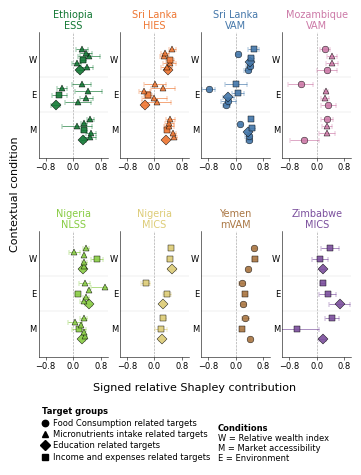

In [93]:
plot_shapley_subplot_grid(
    df=shapley_final,
    metric="imp_emd_over",
    value_col="shapley_mean_share",
    err_col="shapley_se_share",
    out_path=str(BASE_DIR / "shapley_subplot_grid_imp_emd_over_share.png"),
)